In [33]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

In [3]:
# Cada archivo BD {año}.xlsx contiene una hoja por estación de monitoreo,
# con mediciones horarias de contaminantes y variables meteorológicas
# NOTA: BD 2025.xlsx es un año parcial (enero-junio); se incluye en el dataset pero
# hay que tratarlo con cuidado en comparaciones anuales (ver sección 2.1). Además,
# a diferencia de 2020-2024, sus hojas traen una fila extra de unidades (p. ej. "ppm",
# "ppb") como si fuera un registro más; esa fila no tiene fecha válida, así que se
# descarta, y las columnas numéricas se fuerzan a tipo numérico por si acaso

DATA_DIR = Path("data")
YEARS = range(2020, 2026)

frames = []
for year in YEARS:
    path = DATA_DIR / f"BD {year}.xlsx"
    sheets = pd.read_excel(path, sheet_name=None, engine="openpyxl")
    for estación, sheet_df in sheets.items():
        sheet_df = sheet_df.rename(columns={"Fecha y hora": "fecha_hora", "date": "fecha_hora"})
        sheet_df = sheet_df[sheet_df["fecha_hora"].notna()].copy()
        for col in sheet_df.columns.drop("fecha_hora"):
            sheet_df[col] = pd.to_numeric(sheet_df[col], errors="coerce")
        sheet_df["estación"] = estación
        sheet_df["año_archivo"] = year
        frames.append(sheet_df)

df = pd.concat(frames, ignore_index=True)
df["estación"] = df["estación"].astype("category")
df = df.sort_values(["estación", "fecha_hora"]).reset_index(drop=True)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 688,184 | Columnas: 18


,fecha_hora,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,estación,año_archivo
0,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CE,2020
1,2020-01-01 01:00:00,3.28,3.3,6.5,9.8,19.0,112.01,85.64,713.6,0.0,91.0,3.3,0.158,10.49,3.7,2.0,CE,2020
2,2020-01-01 02:00:00,3.35,3.1,5.6,8.8,18.0,100.01,72.39,712.8,0.0,91.0,3.0,0.156,10.51,1.9,144.0,CE,2020
3,2020-01-01 03:00:00,3.22,3.2,7.2,10.4,14.0,106.20,70.25,712.4,0.0,92.0,2.9,0.158,10.64,2.7,28.0,CE,2020
4,2020-01-01 04:00:00,3.26,4.7,10.6,15.3,5.0,141.86,93.72,712.0,0.0,92.0,3.3,0.163,10.73,2.0,31.0,CE,2020


# 1) Comprensión de los datos

## 1.1 Dimensión del dataset y descripción de variables

La base combina 6 archivos anuales (2020-2025) de SIMA (Sistema de Monitoreo Atmosférico), cada uno con una hoja de Excel por estación de monitoreo. El número de estaciónes creció de 13 (2020) a 15 (2022-2025), por lo que la serie es un panel **no balanceado** estación×tiempo. `BD 2025.xlsx` solo cubre enero-junio (año parcial)

| Variable | Descripción | Tipo | Unidad típica* | Rango físico esperado |
|---|---|---|---|---|
| `fecha_hora` | Fecha y hora de la medición (resolución horaria) | Fecha/hora | — | 2020-01-01 a 2025-06-30 |
| `estación` | Clave de la estación de monitoreo (CE, NE, NO, SE, SO, SUR, NTE, y variantes numeradas 2/3 para estaciónes adicionales en la misma zona) | Categórico | — | 13-15 categorías |
| `año_archivo` | Año del archivo fuente (control de trazabilidad, redundante con `fecha_hora`) | Categórico/Numérico | — | 2020-2025 |
| `CO` | Monóxido de carbono | Numérico continuo | ppm | ≥ 0 |
| `NO` | Óxido nítrico | Numérico continuo | ppb | ≥ 0 |
| `NO2` | Dióxido de nitrógeno | Numérico continuo | ppb | ≥ 0 |
| `NOX` | Óxidos de nitrógeno totales (NO + NO2) | Numérico continuo | ppb | ≥ 0, ≥ NO2 |
| `O3` | Ozono | Numérico continuo | ppb | ≥ 0 |
| `PM10` | Partículas suspendidas ≤ 10 micrómetros | Numérico continuo | µg/m³ | ≥ 0 |
| `PM2.5` | Partículas suspendidas ≤ 2.5 micrómetros | Numérico continuo | µg/m³ | ≥ 0, ≤ PM10 |
| `PRS` | Presión barométrica | Numérico continuo | mmHg | > 0 |
| `RAINF` | Precipitación pluvial acumulada en la hora | Numérico continuo | mm | ≥ 0 |
| `RH` | Humedad relativa | Numérico continuo | % | 0-100 |
| `SO2` | Dióxido de azufre | Numérico continuo | ppb | ≥ 0 |
| `SR` | Radiación solar | Numérico continuo | W/m² | ≥ 0 |
| `TOUT` | Temperatura ambiente exterior | Numérico continuo | °C | rango templado |
| `WSR` | Velocidad del viento | Numérico continuo | m/s | ≥ 0 |
| `WDR` | Dirección del viento | Numérico continuo (circular) | grados | 0-360 |

\* Unidades reportadas según el catálogo de parámetros público de SIMA; **conviene confirmarlas contra la documentación oficial de SIMA/SIMAJ** antes de reportarlas en el informe, ya que no vienen especificadas dentro del archivo


In [4]:
print(f"Dimensión: {df.shape[0]:,} registros x {df.shape[1]} columnas\n")
df.info()

Dimensión: 688,184 registros x 18 columnas

<class 'pandas.DataFrame'>
RangeIndex: 688184 entries, 0 to 688183
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   fecha_hora   688184 non-null  datetime64[us]
 1   CO           597323 non-null  float64       
 2   NO           567471 non-null  float64       
 3   NO2          561853 non-null  float64       
 4   NOX          567251 non-null  float64       
 5   O3           582086 non-null  float64       
 6   PM10         657086 non-null  float64       
 7   PM2.5        518607 non-null  float64       
 8   PRS          653561 non-null  float64       
 9   RAINF        654711 non-null  float64       
 10  RH           616677 non-null  float64       
 11  SO2          580284 non-null  float64       
 12  SR           662800 non-null  float64       
 13  TOUT         643176 non-null  float64       
 14  WSR          638428 non-null  float64       
 15  W

In [5]:
# Cobertura por estación y por año
cobertura = (
    df.assign(año=df["fecha_hora"].dt.year)
    .groupby(["estación", "año"], observed=True)
    .size()
    .unstack(fill_value=0)
)
cobertura

año,2020,2021,2022,2023,2024,2025
estación,,,,,,
CE,8784,8760,8760,8758,8784,4344
NE,8776,8759,8760,8758,8784,4343
NE2,8776,8759,8760,8758,8782,4342
NE3,0,8759,8760,8757,8782,4320
NO,8778,8759,8760,8758,8783,4343
NO2,8776,8759,8760,8759,8782,4343
NO3,0,0,743,8759,8784,4320
NTE,8777,8759,8760,8758,8782,4344
NTE2,8776,8759,8760,8758,8782,4343


## 1.2 Calidad de los datos: valores faltantes, duplicados y valores espurios

In [6]:
# Valores faltantes por variable
faltantes = df.isna().sum().to_frame("n_faltantes")
faltantes["pct_faltantes"] = (faltantes["n_faltantes"] / len(df) * 100).round(2)
faltantes.sort_values("pct_faltantes", ascending=False)

,n_faltantes,pct_faltantes
PM2.5,169577,24.64
NO2,126331,18.36
NOX,120933,17.57
NO,120713,17.54
SO2,107900,15.68
O3,106098,15.42
CO,90861,13.20
RH,71507,10.39
WDR,61191,8.89
WSR,49756,7.23


In [7]:
# Faltantes por estación
faltantes_por_estación = (
    df.groupby("estación", observed=True)
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
faltantes_por_estación

,fecha_hora,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SO2,SR,TOUT,WSR,WDR,año_archivo
estación,,,,,,,,,,,,,,,,,
CE,0.0,3.0,9.2,7.1,7.3,7.7,3.0,13.9,1.9,1.8,2.2,4.9,1.4,1.8,2.0,1.9,0.0
NE,0.0,12.4,15.7,23.6,23.2,25.1,3.4,7.1,5.2,4.2,5.7,24.0,2.7,21.5,14.1,8.2,0.0
NE2,0.0,16.1,27.5,27.7,26.6,23.7,5.3,27.3,2.8,2.4,4.0,12.0,0.8,2.6,14.0,9.5,0.0
NE3,0.0,6.4,7.6,7.4,7.0,5.6,6.0,100.0,4.9,3.8,4.0,40.1,12.1,4.5,6.5,4.0,0.0
NO,0.0,28.9,20.9,25.4,24.6,26.4,6.0,41.4,3.3,2.8,13.1,18.8,2.4,12.9,6.1,11.4,0.0
NO2,0.0,2.9,11.1,15.9,10.2,7.1,2.9,14.9,4.1,1.9,4.8,11.7,20.2,2.6,4.2,7.7,0.0
NO3,0.0,11.7,30.9,30.8,30.0,8.5,4.8,89.7,1.2,1.1,35.5,6.9,1.3,1.2,9.7,2.1,0.0
NTE,0.0,24.7,26.8,26.4,26.5,24.8,9.1,15.5,22.7,21.7,54.7,28.9,9.2,21.5,19.7,22.3,0.0
NTE2,0.0,5.8,18.3,19.2,19.2,20.9,3.6,14.7,1.2,1.1,1.5,26.3,0.4,1.1,1.1,1.2,0.0


In [8]:
# Duplicados: filas 100% idénticas y duplicados de llave (misma estación + misma hora)
dup_totales = df.duplicated().sum()
dup_llave = df.duplicated(subset=["estación", "fecha_hora"]).sum()
print(f"Filas totalmente duplicadas: {dup_totales:,}")
print(f"Duplicados de llave (estación, fecha_hora): {dup_llave:,}")

Filas totalmente duplicadas: 0
Duplicados de llave (estación, fecha_hora): 0


In [9]:
# Estadísticos descriptivos: revisamos mínimos/máximos para detectar valores físicamente imposibles
contaminantes = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "SO2"]
meteo = ["PRS", "RAINF", "RH", "SR", "TOUT", "WSR", "WDR"]
numericas = contaminantes + meteo

df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
CO,597323.0,1.381216,0.872623,0.0,0.72,1.230,1.87,37.0
NO,567471.0,12.168117,22.144132,0.3,3.00,5.000,11.20,945.1
NO2,561853.0,14.529999,11.446469,0.0,6.50,11.300,19.40,188.6
NOX,567251.0,26.434722,28.829950,0.5,10.70,17.300,31.00,971.8
O3,582086.0,27.130582,18.924074,0.5,13.00,23.000,37.00,265.0
PM10,657086.0,59.005407,40.850151,1.0,34.00,50.000,72.00,1001.0
PM2.5,518607.0,20.785847,15.655433,0.0,10.74,17.000,27.00,999.0
SO2,580284.0,4.984137,4.727316,0.0,2.90,3.900,5.60,404.7
PRS,653561.0,715.218326,9.511067,0.0,709.50,714.300,721.60,750.0
RAINF,654711.0,0.018993,1.050728,0.0,0.00,0.000,0.00,360.0


In [10]:
# Conteo de valores erróneos según límites físicos conocidos
reglas_espurios = {
    "Concentraciones negativas (contaminantes < 0)": (df[contaminantes] < 0).sum().sum(),
    "RH fuera de [0, 100]%": (~df["RH"].between(0, 100) & df["RH"].notna()).sum(),
    "WDR fuera de [0, 360] grados": (~df["WDR"].between(0, 360) & df["WDR"].notna()).sum(),
    "RAINF negativa": (df["RAINF"] < 0).sum(),
    "WSR negativa": (df["WSR"] < 0).sum(),
    "PM2.5 > PM10 (inconsistencia física)": (df["PM2.5"] > df["PM10"]).sum(),
    "NO2 > NOX (inconsistencia física)": (df["NO2"] > df["NOX"]).sum(),
}
pd.Series(reglas_espurios, name="n_registros_afectados").to_frame()

,n_registros_afectados
Concentraciones negativas (contaminantes < 0),0
"RH fuera de [0, 100]%",278
"WDR fuera de [0, 360] grados",0
RAINF negativa,0
WSR negativa,0
PM2.5 > PM10 (inconsistencia física),32
NO2 > NOX (inconsistencia física),632


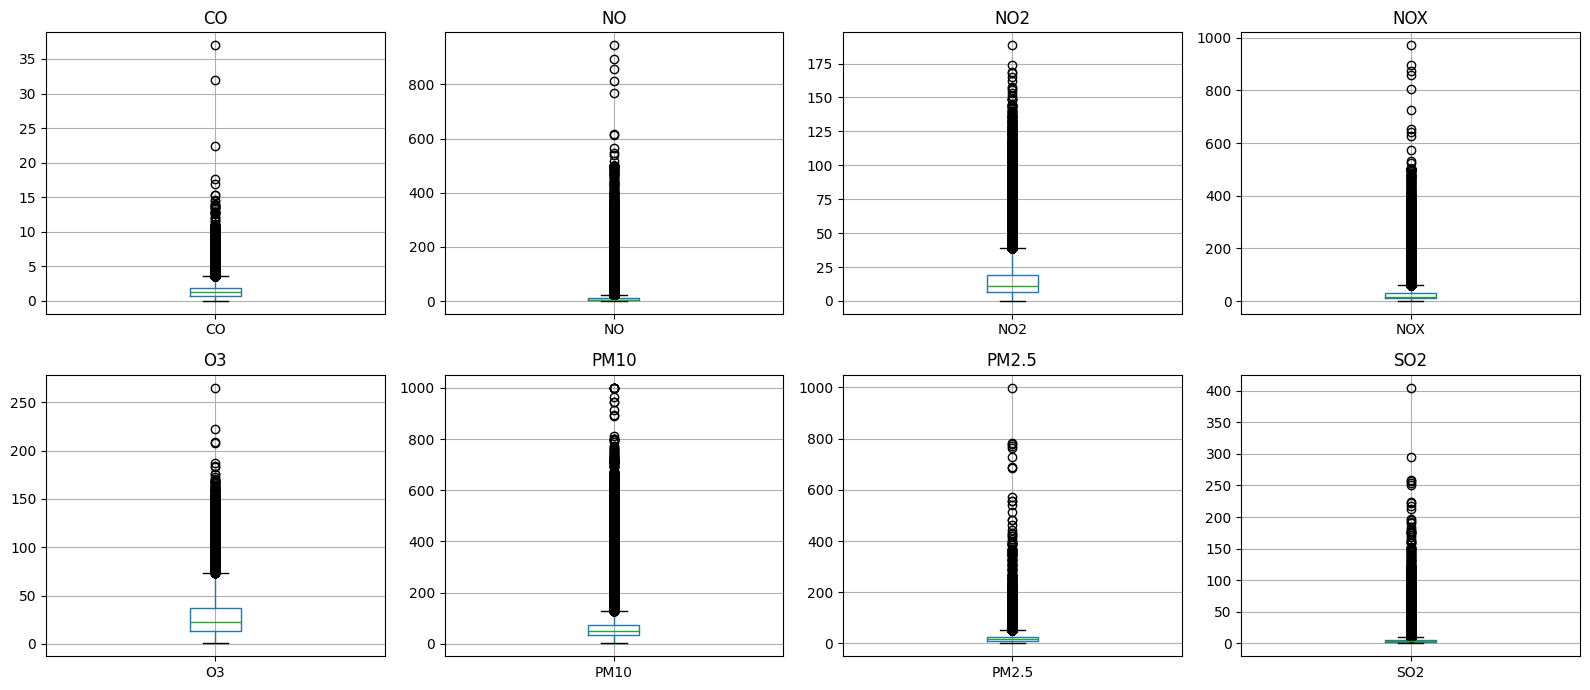

In [11]:
# Visualización de dispersión/outliers por contaminante
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, contaminantes):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 2) Preparación de los datos

## 2.1 Selección del conjunto de datos

- **Incluimos** los 6 archivos 2020-2025 y todas las estaciónes reportadas en cada año, para preservar la mayor cobertura espacial y temporal posible y permitir comparaciones entre zonas de la ciudad.
- `BD 2025.xlsx` es un año **parcial** (enero-junio, ~6 meses): se incluye en `df`/`df_clean` para no perder esos datos, pero cualquier comparación que agregue por año completo (p. ej. la tendencia anual de la sección 5.1) debe tratar 2025 aparte o normalizar por el número de meses disponibles, para no sesgar la comparación frente a los años completos.
- `año_archivo` se conserva solo como control de trazabilidad (para detectar si un archivo fue mal etiquetado); el análisis temporal real debe basarse en `fecha_hora`.

## 2.2 Columnas objetivo

> **Posibles objetivos de indagación** 
> -  **salud pública**: `PM2.5` u `O3` (contaminantes más asociados a efectos respiratorios/cardiovasculares)
> -  **pronóstico**: la variable meteorológica/contaminante a predecir a t+1
> - **comparación espacial**: `estación` como variable de agrupación, no como target numérico


## 2.3 Limpieza de datos

In [12]:
# Duplicados
df_clean = df.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=["estación", "fecha_hora"], keep="first").copy()
print(f"Filas antes: {len(df):,} | después de quitar duplicados: {len(df_clean):,}")

Filas antes: 688,184 | después de quitar duplicados: 688,184


In [13]:
# Valores erróneos
# Criterio: los valores físicamente imposibles se tratan como NaN (no se inventan, se marcan
# como faltantes y se manejan en el siguiente paso). Esto es distinto de un outlier extremo
# pero físicamente posible (p. ej. un pico real de PM2.5 por incendio), que NO se toca aquí

for col in contaminantes:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

df_clean.loc[~df_clean["RH"].between(0, 100), "RH"] = np.nan
df_clean.loc[~df_clean["WDR"].between(0, 360), "WDR"] = np.nan
df_clean.loc[df_clean["RAINF"] < 0, "RAINF"] = np.nan
df_clean.loc[df_clean["WSR"] < 0, "WSR"] = np.nan

print("Valores erróneos corregidos (convertidos a NaN):")
for regla, n in reglas_espurios.items():
    print(f"  - {regla}: {n:,}")

Valores erróneos corregidos (convertidos a NaN):
  - Concentraciones negativas (contaminantes < 0): 0
  - RH fuera de [0, 100]%: 278
  - WDR fuera de [0, 360] grados: 0
  - RAINF negativa: 0
  - WSR negativa: 0
  - PM2.5 > PM10 (inconsistencia física): 32
  - NO2 > NOX (inconsistencia física): 632


### 2.3.1 Valores centinela, rangos físicos e inconsistencias entre variables

El bloque anterior corrige signos, pero **solo detecta** (no elimina) dos inconsistencias físicas: `PM2.5 > PM10` y `NO2 > NOX`. Además, el `describe()` de la sección 1.2 muestra otro problema que quedaba sin atender: varias columnas traen el **código centinela `-9999`** que SIMA usa para "sin dato", junto con valores altos imposibles — `TOUT` = 785 °C, `PRS` = 0 mmHg, `WSR` = 227 m/s, `RAINF` = 360 mm en una hora, y `PM10`/`PM2.5` pegados a ~1000 (el tope de escala del instrumento).

Estos valores hay que quitarlos **antes** de interpolar. Si no, la interpolación lineal los arrastra a las horas vecinas: en la versión previa de la base quedaban temperaturas de −9994, −9990, … como resultado de interpolar entre un dato real y un −9999.

Criterio, igual que antes: lo físicamente imposible se convierte a `NaN` (no se corrige el valor, se trata como faltante y lo maneja el paso de interpolación). Para los contaminantes solo se fija un **tope superior de cordura** que atrapa la saturación del sensor (~1000 µg/m³) sin borrar picos reales por incendios o tolvaneras. Las unidades de `SR` y `WSR` no vienen confirmadas en el archivo fuente, así que sus límites son deliberadamente amplios y solo eliminan lo groseramente imposible (queda pendiente confirmarlas con SIMA/SIMAJ y, si aplica, revisar su cola alta).

> Nota: la interpolación posterior podría reintroducir alguna inconsistencia `PM2.5 > PM10` puntual al interpolar cada columna por separado; si eso importa para el análisis, conviene repetir esa verificación después de interpolar.


In [ ]:
# --- (a) Inconsistencias fisicas entre variables ---
# El bloque anterior SOLO las detecto; aqui si se aplican. PM2.5 es un subconjunto
# de PM10 y NOX = NO + NO2, asi que por definicion PM2.5 <= PM10 y NO2 <= NOX.
# Como no sabemos cual sensor fallo, se anulan ambas columnas en la fila afectada.
inconsistente_pm = df_clean["PM2.5"] > df_clean["PM10"]
inconsistente_nox = df_clean["NO2"] > df_clean["NOX"]
df_clean.loc[inconsistente_pm, ["PM2.5", "PM10"]] = np.nan
df_clean.loc[inconsistente_nox, ["NO2", "NOX"]] = np.nan
print(f"PM2.5 > PM10 -> {int(inconsistente_pm.sum()):,} filas anuladas (PM2.5 y PM10)")
print(f"NO2   > NOX  -> {int(inconsistente_nox.sum()):,} filas anuladas (NO2 y NOX)")

# --- (b) Centinelas (-9999) y rangos fisicamente plausibles para la ZMM ---
# Fuera de rango -> NaN, con el mismo criterio del paso anterior: no se corrige el
# valor, se trata como faltante. Meteorologia: limites reales de la zona con margen.
# Contaminantes: solo un tope superior de cordura que atrapa la saturacion del
# sensor (~1000 ug/m3) sin borrar picos reales por incendios o tolvaneras.
# SR y WSR tienen unidad sin confirmar en el archivo fuente, asi que sus limites son
# amplios a proposito y solo eliminan lo groseramente imposible.
RANGOS_FISICOS = {
    "TOUT":  (-15, 55),     # grados C
    "PRS":   (670, 780),    # mmHg (~540 m de altitud); PRS = 0 y 364 son centinelas
    "RH":    (0, 100),      # %   (ya aplicado antes; se repite por completitud)
    "SR":    (-1, 15),      # radiacion solar; -9999 es centinela
    "WSR":   (0, 100),      # velocidad del viento; se quita solo lo imposible
    "WDR":   (0, 360),      # grados (ya aplicado antes)
    "RAINF": (0, 100),      # mm acumulados en una hora
    "PM10":  (0, 995),      # ug/m3; >~1000 = saturacion del instrumento
    "PM2.5": (0, 900),      # ug/m3; idem
}

print("\nValores fuera de rango fisico (se convierten a NaN):")
n_total = 0
for col, (lim_inf, lim_sup) in RANGOS_FISICOS.items():
    fuera = pd.Series(False, index=df_clean.index)
    if lim_inf is not None:
        fuera |= df_clean[col] < lim_inf
    if lim_sup is not None:
        fuera |= df_clean[col] > lim_sup
    fuera &= df_clean[col].notna()
    n = int(fuera.sum())
    n_total += n
    if n:
        vals = df_clean.loc[fuera, col]
        print(f"  - {col:5s} fuera de ({lim_inf}, {lim_sup}): {n:>4,} registros "
              f"[min {vals.min():.1f}, max {vals.max():.1f}]")
    df_clean.loc[fuera, col] = np.nan
print(f"\nTotal marcado como NaN por rango fisico: {n_total:,}")

# Verificacion: ya no deben quedar centinelas ni maximos imposibles
print("\nMin / max por variable tras la limpieza:")
df_clean[list(RANGOS_FISICOS)].agg(["min", "max"]).T


In [14]:
# Valores faltantes
# Al ser series de tiempo por estación, interpolamos SOLO huecos cortos (<=3 horas), que
# suelen deberse a fallas puntuales de transmisión del sensor. Huecos largos (mantenimiento,
# sensor caído varios días) se dejan como NaN: rellenarlos inventaría información que no
# tenemos, y para muchos análisis (promedios, KPIs regulatorios) es mejor excluir el hueco
# que sesgarlo con datos interpolados poco confiables
df_clean = df_clean.sort_values(["estación", "fecha_hora"])

MAX_HUECO_HORAS = 3
for col in numericas:
    df_clean[col] = df_clean.groupby("estación", observed=True)[col].transform(
        lambda s: s.interpolate(method="linear", limit=MAX_HUECO_HORAS, limit_direction="both")
    )

pct_tras_interpolar = (df_clean[numericas].isna().mean() * 100).round(2)
pct_tras_interpolar.to_frame("pct_faltantes_tras_interpolar")

,pct_faltantes_tras_interpolar
CO,11.84
NO,14.09
NO2,15.94
NOX,15.16
O3,12.88
PM10,2.61
PM2.5,19.06
SO2,11.35
PRS,3.79
RAINF,3.92


## 2.4 Datos categóricos

La única variable categórica real es `estación` (13-15 niveles). No convertimos a variables *dummy* de forma automática porque:
- Para análisis exploratorio, series de tiempo y modelos basados en árboles (Random Forest, XGBoost), `estación` puede usarse directamente como categoría — no necesita one-hot encoding
- Las *dummies* (one-hot) son necesarias si más adelante se ajusta un modelo **lineal** (regresión lineal/logística) que requiera variables puramente numéricas, o si se quiere usar `estación` como efecto fijo en un modelo de regresión

Dejamos el encoding como paso condicional, a aplicar solo si el modelo elegido en la Parte I lo requiere:

In [15]:
#  one-hot encoding de estación, solo si el modelo lo requiere
df_dummies_ejemplo = pd.get_dummies(df_clean["estación"], prefix="estación")
df_dummies_ejemplo.head()

,estación_CE,estación_NE,estación_NE2,estación_NE3,estación_NO,estación_NO2,estación_NO3,estación_NTE,estación_NTE2,estación_SE,estación_SE2,estación_SE3,estación_SO,estación_SO2,estación_SUR
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 2.5 Valores atípicos (outliers)

Importante: en datos de contaminación, un valor extremo (p. ej. PM2.5 muy alto por incendios forestales, quema agrícola, o una inversión térmica) puede ser un **evento real y relevante**, no un error. Por eso no eliminamos outliers automáticamente: los **detectamos y marcamos** con una bandera booleana por variable (método IQR, calculado por estación para respetar las diferencias entre zonas).

In [16]:
def marcar_outliers_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - k * iqr, q3 + k * iqr
    return ~s.between(lim_inf, lim_sup) & s.notna()

for col in contaminantes:
    df_clean[f"{col}_outlier"] = df_clean.groupby("estación", observed=True)[col].transform(marcar_outliers_iqr)

outlier_cols = [f"{col}_outlier" for col in contaminantes]
print("% de registros marcados como outlier por variable (dentro de su estación):")
(df_clean[outlier_cols].mean() * 100).round(2)

% de registros marcados como outlier por variable (dentro de su estación):


CO_outlier        1.50
NO_outlier       10.19
NO2_outlier       3.75
NOX_outlier       6.98
O3_outlier        2.04
PM10_outlier      4.70
PM2.5_outlier     2.84
SO2_outlier       6.85
dtype: float64

# 3) Transformación de datos

## 3.1 Atributos derivados

A partir de `fecha_hora` construimos atributos de calendario que casi cualquier análisis de calidad del aire necesita, porque la contaminación tiene fuertes patrones horarios (tráfico), semanales (entre semana vs. fin de semana) y estaciónales (temporada seca vs. lluvias)

In [17]:
df_clean["año"] = df_clean["fecha_hora"].dt.year
df_clean["mes"] = df_clean["fecha_hora"].dt.month
df_clean["hora"] = df_clean["fecha_hora"].dt.hour
df_clean["dia_semana"] = df_clean["fecha_hora"].dt.dayofweek  # 0 = lunes
df_clean["es_fin_de_semana"] = df_clean["dia_semana"] >= 5


def temporada_s(mes):
    # Clasificación climática
    if mes in (11, 12, 1, 2):
        return "seca-fria"
    elif mes in (3, 4, 5):
        return "seca-calida"
    else:
        return "lluvias"


df_clean["temporada"] = df_clean["mes"].apply(temporada_s).astype("category")
df_clean[["fecha_hora", "año", "mes", "hora", "dia_semana", "es_fin_de_semana", "temporada"]].head()

,fecha_hora,año,mes,hora,dia_semana,es_fin_de_semana,temporada
0,2020-01-01 00:00:00,2020,1,0,2,False,seca-fria
1,2020-01-01 01:00:00,2020,1,1,2,False,seca-fria
2,2020-01-01 02:00:00,2020,1,2,2,False,seca-fria
3,2020-01-01 03:00:00,2020,1,3,2,False,seca-fria
4,2020-01-01 04:00:00,2020,1,4,2,False,seca-fria


## 3.2 Discretización (binning)

México clasifica la calidad del aire con el índice IMECA/AICA, que tiene umbrales oficiales específicos por contaminante (definidos en las NOM correspondientes, p. ej. NOM-020-SSA1 para O3 y PM2.5, NOM-025-SSA1 para PM10). **No hardcodeamos esos umbrales aquí** porque deben tomarse de la norma oficial vigente (parte de la investigación bibliográfica de la Parte I), no inventarse. Mientras tanto, mostramos una discretización **ilustrativa** por cuartiles, solo para ver cómo se vería una variable categórica derivada de una continua — debe sustituirse por los cortes oficiales del IMECA una vez confirmados

In [18]:
# cortes oficiales del IMECA/NOM 
df_clean["PM2.5_nivel_cuartil"] = pd.qcut(
    df_clean["PM2.5"], q=4, labels=["bajo", "medio", "alto", "muy_alto"]
)
df_clean["PM2.5_nivel_cuartil"].value_counts()

PM2.5_nivel_cuartil
medio       145828
bajo        139257
muy_alto    139216
alto        132708
Name: count, dtype: int64

## 3.3 Escalamiento y normalización

Las variables están en escalas muy distintas (CO en ppm ~0-5, PM10 en µg/m³ ~0-300, WDR en grados 0-360). Esto **no hace falta** para reportes descriptivos, series de tiempo o modelos de árboles, pero **sí es necesario** si más adelante se usa un modelo sensible a la escala (regresión con regularización, KNN, redes neuronales, PCA, clustering). Guardamos una versión escalada aparte (`df_scaled`), sin sobreescribir los valores originales interpretables

In [19]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_clean.copy()
scaler = StandardScaler()
df_scaled[numericas] = scaler.fit_transform(df_clean[numericas])
df_scaled[numericas].describe().T[["mean", "std"]]

,mean,std
CO,-2.158757e-16,1.000001
NO,-2.153604e-17,1.000001
NO2,-1.194898e-16,1.000001
NOX,1.137129e-16,1.000001
O3,1.820306e-17,1.000001
PM10,8.142395e-18,1.000001
PM2.5,-1.959382e-17,1.000001
SO2,-4.174210e-17,1.000001
PRS,2.351592e-15,1.000001
RAINF,6.533904e-18,1.000001


# 4) Reestructuración de los datos

El formato actual de `df_clean` ya es **long/tidy**: cada fila es una observación (una estación, una hora), cada columna una variable. Este formato es el más flexible para explorar, filtrar y modelar. La única reestructuración adicional depende de cómo se vaya a usar la información:

- Para comparar estaciónes lado a lado en el tiempo → `pivot` a formato ancho, una columna por estación (útil para gráficas de series de tiempo superpuestas)
- Para agregación diaria/mensual (p. ej. promedios regulatorios) → `groupby` de `estación` + fecha truncada a día/mes

Se muestran ambos como ejemplos, sin sobreescribir `df_clean`:

In [20]:
# PM2.5 por estación en columnas
pm25_ancho = df_clean.pivot_table(index="fecha_hora", columns="estación", values="PM2.5", observed=True)
pm25_ancho.head()

estación,CE,NE,NE2,NO,NO2,NO3,NTE,NTE2,SE,SE2,SE3,SO,SO2,SUR
fecha_hora,,,,,,,,,,,,,,
2020-01-01 00:00:00,85.64,107.550,22.000000,70.81,86.930,NaN,49.71,62.0,54.230,NaN,18.0,59.26,37.0,11.0
2020-01-01 01:00:00,85.64,76.055,17.666667,76.73,79.430,NaN,46.70,54.0,54.035,NaN,28.0,51.43,37.0,11.0
2020-01-01 02:00:00,72.39,44.560,13.333333,82.65,71.930,NaN,44.42,46.0,53.840,NaN,28.0,50.88,42.0,21.0
2020-01-01 03:00:00,70.25,43.665,9.000000,51.16,64.910,NaN,46.84,38.0,36.470,NaN,11.0,47.99,36.0,31.0
2020-01-01 04:00:00,93.72,42.770,8.500000,56.29,67.362,NaN,33.15,25.0,33.590,NaN,10.0,49.90,47.0,12.0


In [21]:
# promedio diario por estación (agregación típica para reportes regulatorios)
promedio_diario = (
    df_clean.groupby(["estación", df_clean["fecha_hora"].dt.date], observed=True)[numericas]
    .mean()
    .reset_index()
    .rename(columns={"fecha_hora": "fecha"})
)
promedio_diario.head()

,estación,fecha,CO,NO,NO2,NOX,O3,PM10,PM2.5,SO2,PRS,RAINF,RH,SR,TOUT,WSR,WDR
0,CE,2020-01-01,3.157500,4.120833,6.650000,10.775000,15.625000,66.160417,41.560417,2.716667,711.254167,0.0,89.125000,0.159917,12.279583,2.466667,189.958333
1,CE,2020-01-02,3.245000,8.412500,9.229167,17.637500,19.166667,37.528750,9.342083,2.879167,705.408333,0.0,62.083333,0.168708,16.812917,3.762500,201.500000
2,CE,2020-01-03,2.916250,4.558333,6.325000,10.883333,32.791667,37.939583,8.061667,3.637500,711.533333,0.0,35.291667,0.166542,17.174583,9.875000,260.666667
3,CE,2020-01-04,3.024583,5.670833,9.579167,15.245833,25.750000,47.499583,16.165833,3.916667,719.620833,0.0,39.166667,0.172625,14.604583,3.679167,179.958333
4,CE,2020-01-05,3.157500,5.025000,12.058333,17.033333,25.854167,62.838333,27.457500,7.495833,718.254167,0.0,40.083333,0.175208,15.855417,3.662500,183.125000


In [22]:
# Guardamos la base limpia
Path("output").mkdir(exist_ok=True)
df_clean.to_parquet("output/sima_2020_2025_limpio.parquet", index=False)
print(f"Guardado: output/sima_2020_2025_limpio.parquet ({len(df_clean):,} filas)")

Guardado: output/sima_2020_2025_limpio.parquet (688,184 filas)


# 5) Exploración para definir el objetivo de indagación

Ahora, exploramos patrones visibles en los datos: tendencia a lo largo de los años, patrón horario (tráfico vs. fotoquímica), diferencias entre estaciónes, y relación con variables meteorológicas. Cualquiera de estos patrones puede convertirse en la pregunta de investigación del proyecto

## 5.1 Tendencia anual (promedio de la ciudad, todas las estaciónes)

¿La calidad del aire ha mejorado o empeorado en 2020-2024? 2020 incluye el confinamiento por COVID-19 (menos tráfico), interesante como quiebre natural en la serie. La tendencia se calcula solo con años completos (2020-2024); 2025 es parcial (enero-junio) y se muestra aparte para no sesgar la comparación anual con un año a medias

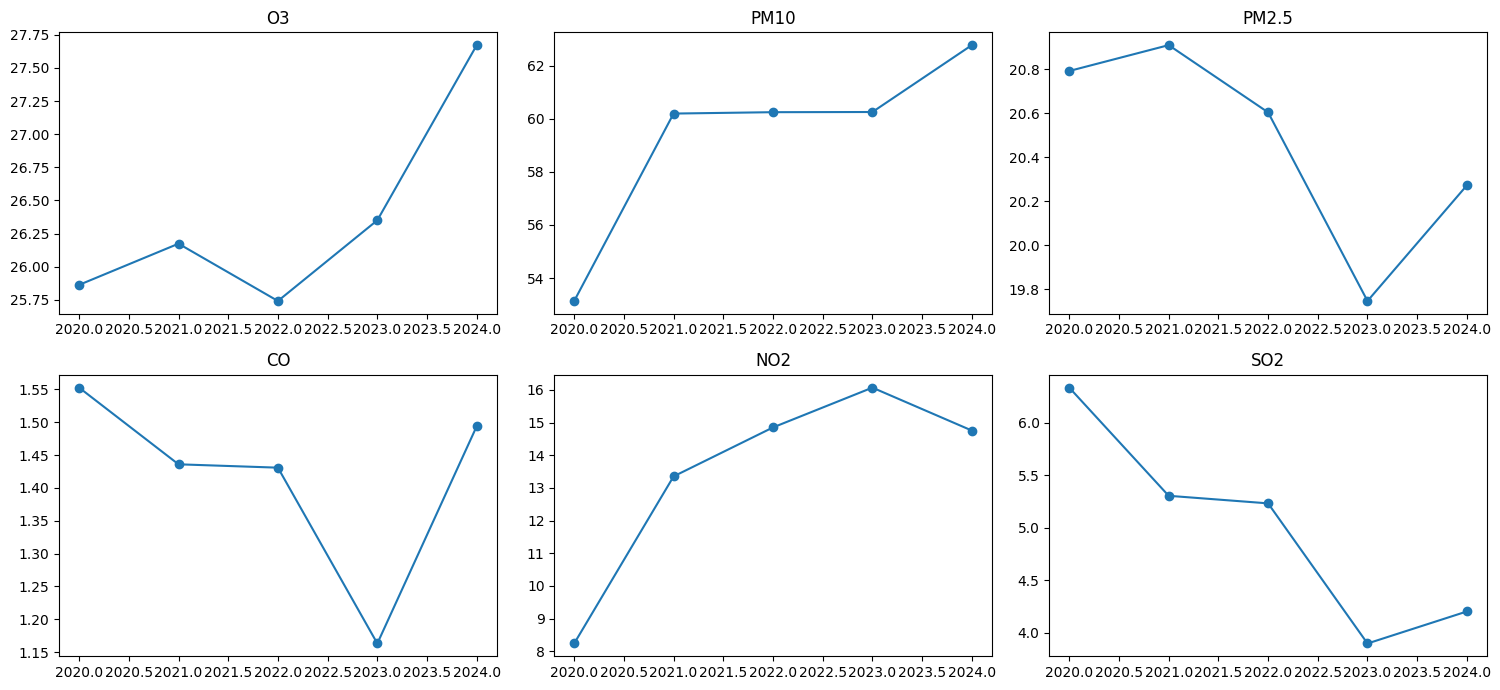

,O3,PM10,PM2.5,CO,NO2,SO2
año,,,,,,
2020,25.862553,53.135694,20.791324,1.552630,8.238097,6.335487
2021,26.173404,60.197282,20.908789,1.435916,13.353260,5.304390
2022,25.741012,60.249359,20.603403,1.430807,14.852199,5.232243
2023,26.350242,60.256047,19.746453,1.163195,16.070400,3.896518
2024,27.671904,62.776037,20.271928,1.493958,14.756515,4.201871


In [23]:
años_completos = [2020, 2021, 2022, 2023, 2024]
cols_tendencia = ["O3", "PM10", "PM2.5", "CO", "NO2", "SO2"]

tendencia_anual = df_clean[df_clean["año"].isin(años_completos)].groupby("año")[cols_tendencia].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, tendencia_anual.columns):
    tendencia_anual[col].plot(ax=ax, marker="o")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

tendencia_anual

In [24]:
# 2025 (enero-junio) aparte: promedio de un año parcial, no comparable directo con años completos
tendencia_2025_parcial = df_clean.loc[df_clean["año"] == 2025, cols_tendencia].mean()
tendencia_2025_parcial.to_frame("2025 (ene-jun, parcial)")

,"2025 (ene-jun, parcial)"
O3,29.513539
PM10,55.540265
PM2.5,21.446109
CO,1.161859
NO2,14.572720
SO2,5.651139


## 5.2 Patrón horario: ¿tráfico (NO2/CO) vs. fotoquímica (O3)?

Los contaminantes primarios (NO2, CO) suelen tener picos en horas de tráfico (mañana/tarde), mientras que el O3 se forma por reacción fotoquímica y su pico es al mediodía/tarde, con retraso respecto a sus precursores. Ver esto en los datos ayuda a decidir si el proyecto se orienta a tráfico vehicular

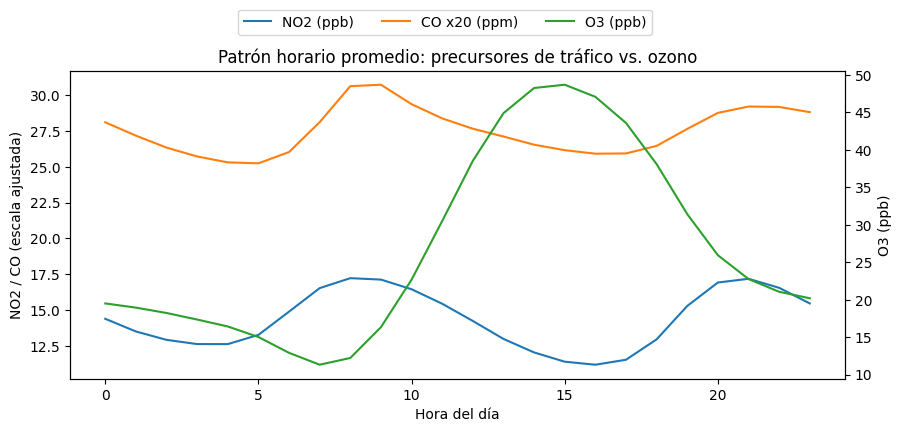

In [25]:
patron_horario = df_clean.groupby("hora")[["NO2", "CO", "O3"]].mean()

fig, ax1 = plt.subplots()
ax1.plot(patron_horario.index, patron_horario["NO2"], color="tab:blue", label="NO2 (ppb)")
ax1.plot(patron_horario.index, patron_horario["CO"] * 20, color="tab:orange", label="CO x20 (ppm)")
ax1.set_xlabel("Hora del día")
ax1.set_ylabel("NO2 / CO (escala ajustada)")
ax2 = ax1.twinx()
ax2.plot(patron_horario.index, patron_horario["O3"], color="tab:green", label="O3 (ppb)")
ax2.set_ylabel("O3 (ppb)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.title("Patrón horario promedio: precursores de tráfico vs. ozono")
plt.show()

## 5.3 Entre semana vs. fin de semana

Si los contaminantes de tráfico bajan claramente el fin de semana, es evidencia de que el tráfico vehicular es una fuente dominante — un ángulo de proyecto posible (p. ej. política de "Hoy No Circula" o transporte)

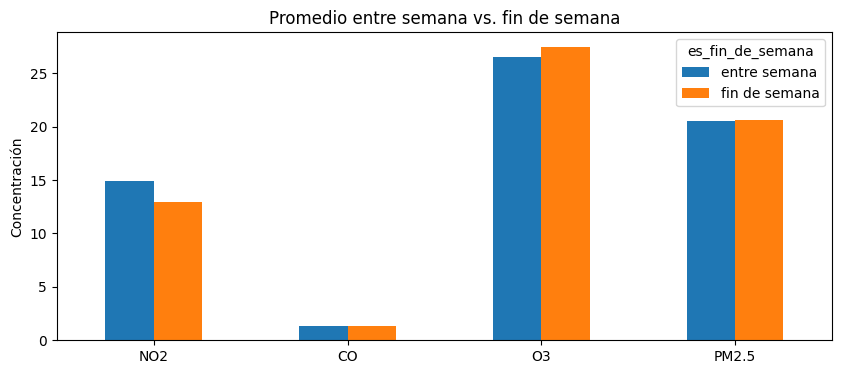

,NO2,CO,O3,PM2.5
es_fin_de_semana,,,,
entre semana,14.905530,1.379199,26.495440,20.498343
fin de semana,12.974244,1.368683,27.462228,20.653590


In [26]:
semana_vs_finde = df_clean.groupby("es_fin_de_semana")[["NO2", "CO", "O3", "PM2.5"]].mean()
semana_vs_finde.index = semana_vs_finde.index.map({False: "entre semana", True: "fin de semana"})
semana_vs_finde.T.plot(kind="bar")
plt.title("Promedio entre semana vs. fin de semana")
plt.ylabel("Concentración")
plt.xticks(rotation=0)
plt.show()

semana_vs_finde

## 5.4 Diferencia entre temporadas (seca-fría, seca-cálida, lluvias)

La lluvia limpia partículas del aire, mientras que la inversión térmica en temporada seca-fría suele atrapar contaminantes cerca del suelo. Ver esta diferencia sugiere un proyecto centrado en meteorología y dispersión de contaminantes

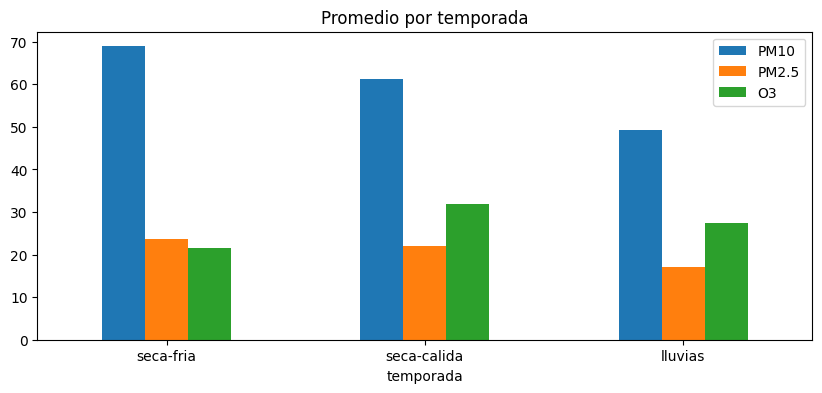

,PM10,PM2.5,O3
temporada,,,
seca-fria,68.892526,23.568589,21.432753
seca-calida,61.255380,22.062281,31.923750
lluvias,49.357442,16.977925,27.370932


In [27]:
temporada_orden = ["seca-fria", "seca-calida", "lluvias"]
por_temporada = df_clean.groupby("temporada", observed=True)[["PM10", "PM2.5", "O3"]].mean().reindex(temporada_orden)
por_temporada.plot(kind="bar")
plt.title("Promedio por temporada")
plt.xticks(rotation=0)
plt.show()

por_temporada

## 5.5 Comparación espacial entre estaciónes

¿Hay zonas de la ciudad consistentemente más contaminadas que otras? Esto sugiere un proyecto de **justicia ambiental** (¿qué zonas/poblaciones están más expuestas?) o de identificación de fuentes locales (industria, vialidades)

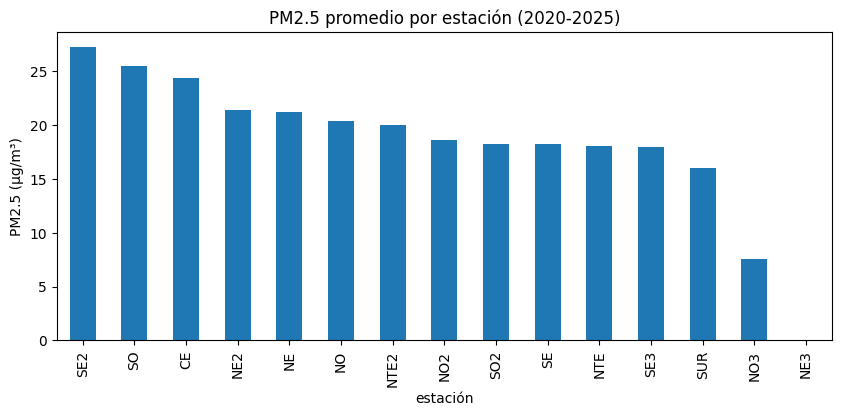

estación
SE2     27.241538
SO      25.517307
CE      24.351498
NE2     21.414302
NE      21.167358
NO      20.354408
NTE2    19.997496
NO2     18.583966
SO2     18.268778
SE      18.244633
NTE     18.005087
SE3     17.916964
SUR     16.023261
NO3      7.556900
NE3           NaN
Name: PM2.5, dtype: float64

In [28]:
por_estación = df_clean.groupby("estación", observed=True)["PM2.5"].mean().sort_values(ascending=False)
por_estación.plot(kind="bar", figsize=(10, 4))
plt.title("PM2.5 promedio por estación (2020-2025)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

por_estación

## 5.6 Correlación entre contaminantes y variables meteorológicas

Si un contaminante correlaciona fuertemente con temperatura, viento o humedad, eso sugiere un proyecto de **pronóstico** (predecir el contaminante a partir del clima) o de **dispersión atmosférica**

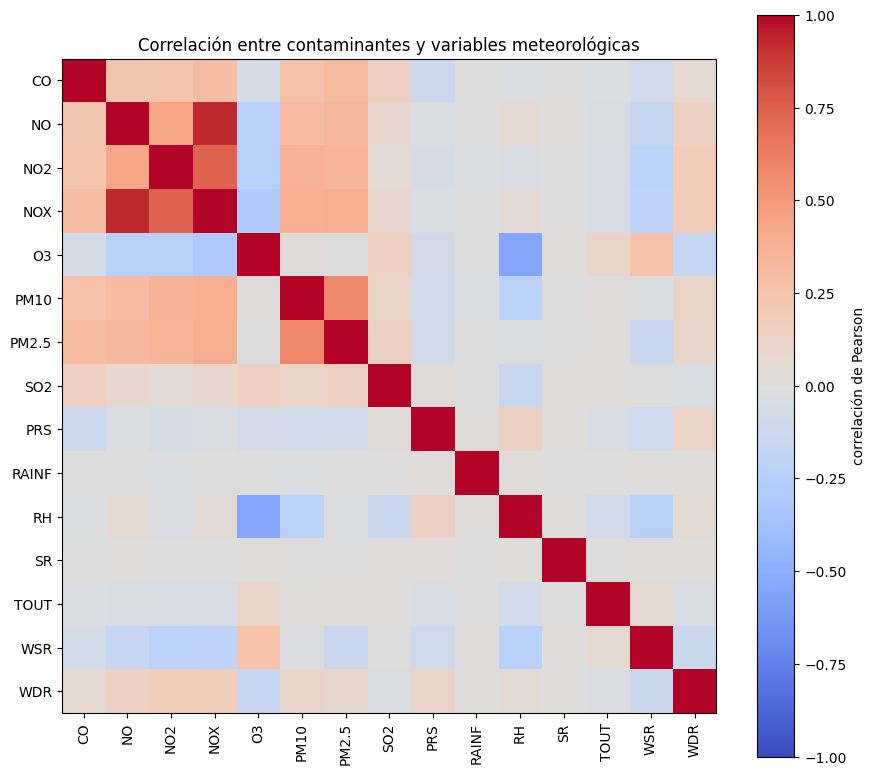

In [29]:
corr = df_clean[numericas].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas)))
ax.set_xticklabels(numericas, rotation=90)
ax.set_yticks(range(len(numericas)))
ax.set_yticklabels(numericas)
fig.colorbar(im, label="correlación de Pearson")
plt.title("Correlación entre contaminantes y variables meteorológicas")
plt.tight_layout()
plt.show()

## 5.7 Cómo usar esta exploración para elegir el objetivo

Tendencia anual (5.1). Lo que más llama la atención es el NO2: pasa de 8.24 ppb en 2020 a 13.35 en 2021, y ya no baja de ahí en todo 2022-2024 (llega a 16.07 en 2023 antes de bajar un poco a 14.76 en 2024). Justo coincide con el fin del confinamiento por COVID, cuando volvió el tráfico. El PM10 también sube con los años (53.1 → 62.8 µg/m³), pero ahí hay que tener cuidado antes de decir "el aire empeoró": entre 2020 y 2024 se agregaron 2 estaciones nuevas, así que parte de esa subida puede ser porque ahora se está midiendo en más puntos de la ciudad, no necesariamente porque haya más contaminación en general. El O3 se queda bastante parejo (25.9 a 27.7) y el SO2 y el CO más bien bajan un poco. 2025 (parcial, enero-junio) muestra promedios más altos que cualquier año completo en varios contaminantes (O3 29.5, PM10 55.5 µg/m³), pero no es directamente comparable con la serie anual: cubre solo la primera mitad del año, que según la sección 5.4 ya tiende a valores más altos por sí misma (temporada seca-fría y seca-cálida), así que ese salto puede ser puramente estacional y no una tendencia real.

Patrón por hora (5.2). Aquí sí se ve clarísimo el efecto del tráfico. El NO2 tiene dos picos: uno como a las 8am (17.22 ppb) y otro como a las 9pm (17.17 ppb), justo las horas pico. El CO hace algo parecido, con su punto más alto a las 9am (1.54 ppm). El O3 va al revés: está en su mínimo justo cuando el tráfico está en su pico de la mañana (11.32 ppb a las 7am) y no llega a su máximo hasta las 3pm (48.69 ppb). Tiene sentido: el ozono no sale directo del escape de los coches, se forma horas después por la reacción de esos gases con el sol.

Entre semana vs. fin de semana (5.3). El NO2 baja de 14.91 a 12.97 ppb el fin de semana (como 13% menos), lo que otra vez apunta al tráfico como fuente. Lo curioso es que el O3 sube un poco el fin de semana (26.50 → 27.46): con menos NOx fresco en el aire hay menos "consumo" de ozono cerca de las fuentes — esto es un efecto que ya está documentado en otros estudios como el "weekend effect" del ozono.

Por temporada (5.4). PM10 y PM2.5 son notablemente más altos en temporada seca-fría (68.9 y 23.6) que en lluvias (49.4 y 17.0): la lluvia lava las partículas y en época seca-fría las inversiones térmicas las atrapan cerca del suelo. El O3, en cambio, es más alto en seca-cálida (31.9), cuando hay más radiación solar para la reacción fotoquímica.

Por estación (5.5). Las diferencias entre zonas son grandes: SE2 tiene el PM2.5 promedio más alto (27.2 µg/m³) y SUR el más bajo entre las estaciones con datos confiables (16.0) — casi el doble. (NO3 y NE3 casi no traen datos porque son estaciones que empezaron a operar después, así que por ahora no son muy comparables con el resto).

Correlaciones (5.6). Lo que más se relaciona con el O3 es la humedad relativa, pero en negativo (-0.55): entre menos húmedo, más ozono. También correlaciona en negativo con NO2 y NOX (-0.26 a -0.30). El PM2.5 se relaciona sobre todo con PM10 (0.58, es casi obvio) y después con los gases de combustión NOx/NO2/CO (0.31-0.39), lo que sugiere que comparten fuente: quema de combustible.

Conclusión. La señal más fuerte y consistente en todos lados es la del tráfico vehicular: se ve en el salto de NO2 post-COVID, en los dos picos horarios de NO2/CO, en la caída de fin de semana, y en que PM2.5 correlaciona más con los gases de combustión que con cualquier variable meteorológica. La comparación entre estaciones (5.5) también da para un ángulo interesante de exposición desigual por zona, pero con menos "historia" detrás que explique el por qué. Por eso me voy a ir por el objetivo de tráfico vehicular como fuente de contaminación y su relación con la exposición ciudadana, usando NO2 y PM2.5 como las variables objetivo principales.

## Conociendo los datos: Decidir si haremos imputación

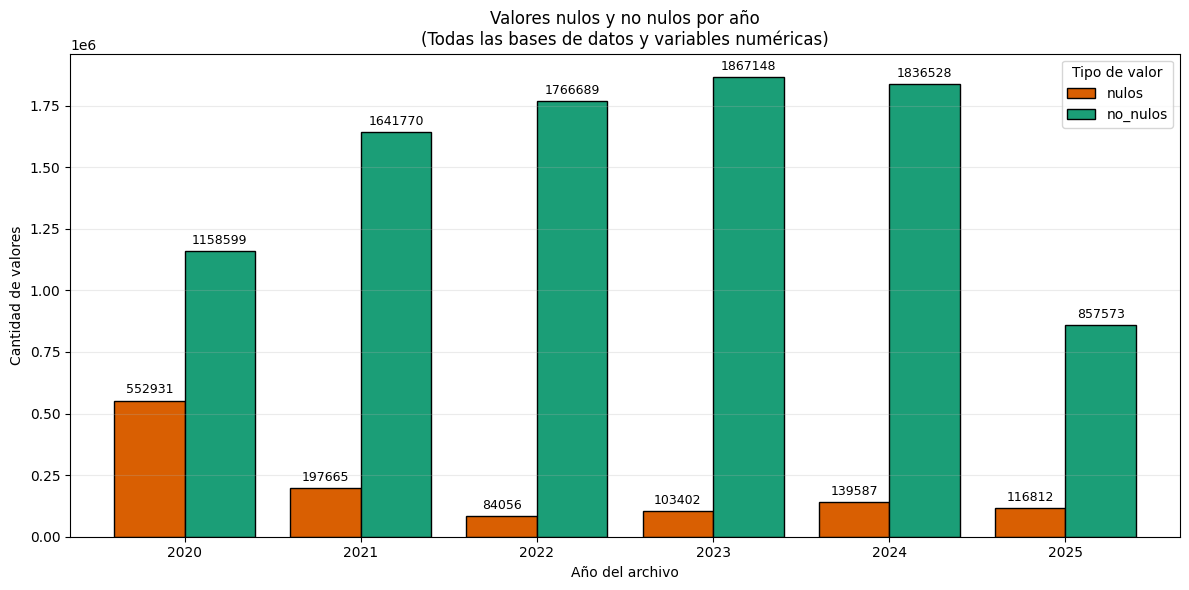

,nulos,no_nulos
año_archivo,,
2020,552931,1158599
2021,197665,1641770
2022,84056,1766689
2023,103402,1867148
2024,139587,1836528
2025,116812,857573


In [30]:
# Comparación de valores nulos y no nulos por año
# Se usa df (antes de interpolar) para conservar los faltantes originales.
conteo_por_año = df.groupby("año_archivo", observed=True)[numericas].apply(
    lambda grupo: pd.Series({
        "nulos": grupo.isna().sum().sum(),
        "no_nulos": grupo.notna().sum().sum(),
    })
)

ax = conteo_por_año.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#D95F02", "#1B9E77"],
    edgecolor="black",
    width=0.8,
)
ax.set_title("Valores nulos y no nulos por año\n(Todas las bases de datos y variables numéricas)")
ax.set_xlabel("Año del archivo")
ax.set_ylabel("Cantidad de valores")
ax.legend(title="Tipo de valor")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

for barras in ax.containers:
    ax.bar_label(barras, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

conteo_por_año

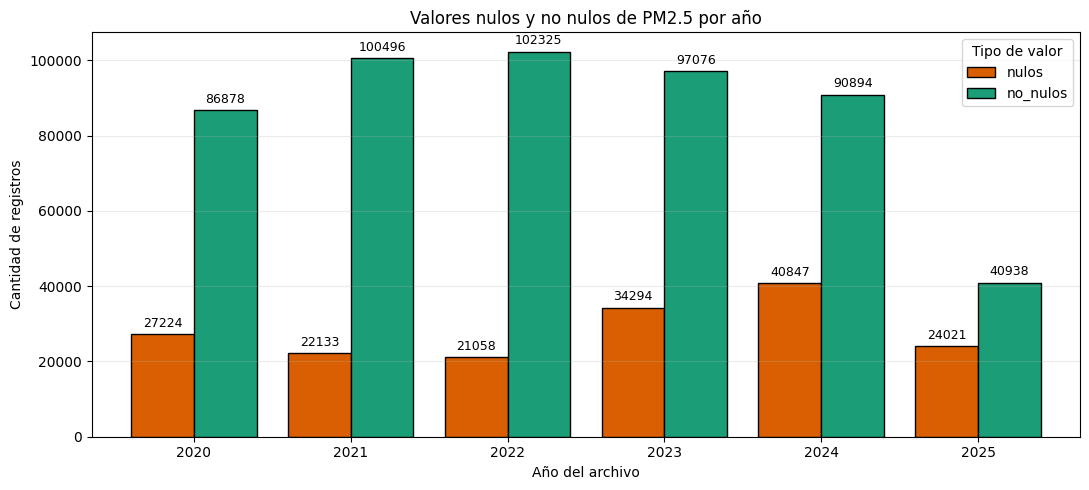

,nulos,no_nulos
año_archivo,,
2020,27224,86878
2021,22133,100496
2022,21058,102325
2023,34294,97076
2024,40847,90894
2025,24021,40938


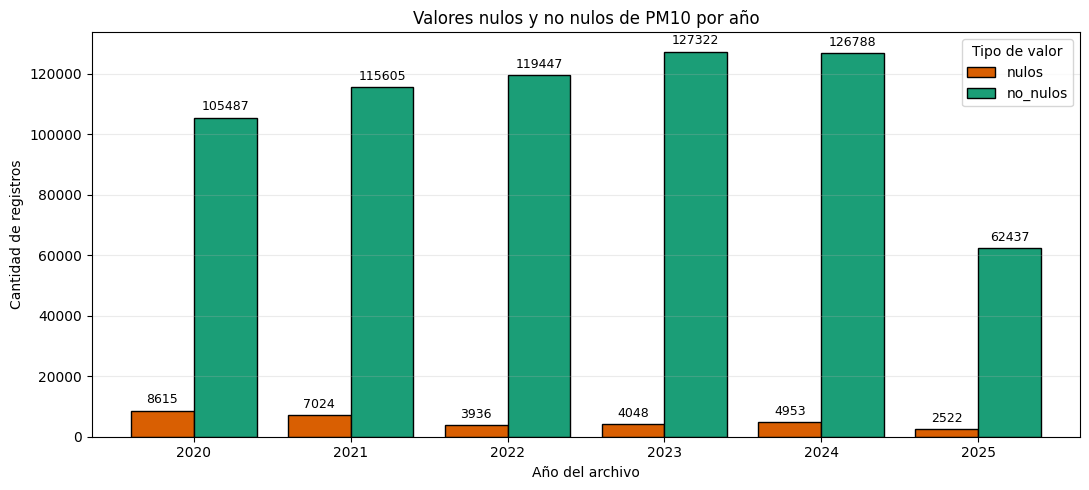

,nulos,no_nulos
año_archivo,,
2020,8615,105487
2021,7024,115605
2022,3936,119447
2023,4048,127322
2024,4953,126788
2025,2522,62437


In [31]:
# Comparación de valores nulos y no nulos para PM2.5 y PM10
for variable in ["PM2.5", "PM10"]:
    conteo_pm = df.groupby("año_archivo", observed=True)[variable].agg(
        nulos=lambda valores: valores.isna().sum(),
        no_nulos=lambda valores: valores.notna().sum(),
    )

    ax = conteo_pm.plot(
        kind="bar",
        figsize=(11, 5),
        color=["#D95F02", "#1B9E77"],
        edgecolor="black",
        width=0.8,
    )
    ax.set_title(f"Valores nulos y no nulos de {variable} por año")
    ax.set_xlabel("Año del archivo")
    ax.set_ylabel("Cantidad de registros")
    ax.legend(title="Tipo de valor")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.25)

    for barras in ax.containers:
        ax.bar_label(barras, fmt="%.0f", padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

    display(conteo_pm)

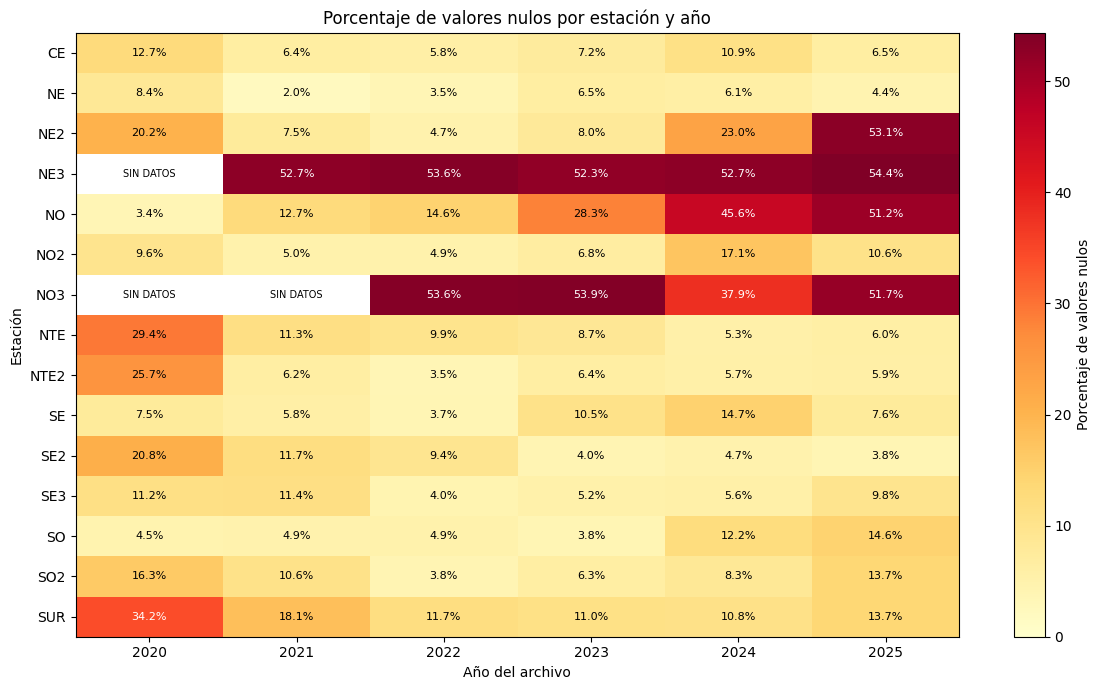

Criterio: estación-año inválido si el porcentaje de nulos es mayor que 25%.
Porcentaje de nulos por estación y año:


Año,2020,2021,2022,2023,2024,2025
Estación,,,,,,
CE,12.69,6.42,5.77,7.23,10.95,6.50
NE,8.41,2.02,3.54,6.53,6.08,4.40
NE2,20.23,7.47,4.67,7.99,22.96,53.06
NE3,NaN,52.70,53.57,52.34,52.74,54.36
NO,3.41,12.73,14.64,28.29,45.61,51.17
NO2,9.63,5.03,4.90,6.77,17.10,10.59
NO3,NaN,NaN,53.63,53.92,37.89,51.67
NTE,29.43,11.34,9.85,8.65,5.32,5.96
NTE2,25.72,6.22,3.49,6.36,5.69,5.87


Estado de cada estación-año:


Año,2020,2021,2022,2023,2024,2025
Estación,,,,,,
CE,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO
NE,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO
NE2,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,INVÁLIDO
NE3,SIN DATOS,INVÁLIDO,INVÁLIDO,INVÁLIDO,INVÁLIDO,INVÁLIDO
NO,VÁLIDO,VÁLIDO,VÁLIDO,INVÁLIDO,INVÁLIDO,INVÁLIDO
NO2,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO
NO3,SIN DATOS,SIN DATOS,INVÁLIDO,INVÁLIDO,INVÁLIDO,INVÁLIDO
NTE,INVÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO
NTE2,INVÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO,VÁLIDO


In [32]:
# Porcentaje de nulos y validación por estación y año
variables_nulas = ["PM10", "PM2.5"]
agrupacion_estacion_año = df.groupby(
    ["estación", "año_archivo"], observed=True
)[variables_nulas]

nulos = agrupacion_estacion_año.apply(lambda grupo: grupo.isna().to_numpy().sum())
no_nulos = agrupacion_estacion_año.apply(lambda grupo: grupo.notna().to_numpy().sum())
conteo_por_estacion_año = pd.DataFrame({"nulos": nulos, "no_nulos": no_nulos})

conteo_total = conteo_por_estacion_año["nulos"] + conteo_por_estacion_año["no_nulos"]
pct_nulos_por_estacion_año = (
    conteo_por_estacion_año["nulos"] / conteo_total * 100
).unstack()
pct_nulos_por_estacion_año = pct_nulos_por_estacion_año.sort_index(axis=1)
pct_nulos_por_estacion_año.index.name = "Estación"
pct_nulos_por_estacion_año.columns.name = "Año"

umbral_nulos = 25
estado_estacion_año = pct_nulos_por_estacion_año.map(
    lambda porcentaje: (
        "SIN DATOS" if pd.isna(porcentaje)
        else "INVÁLIDO" if porcentaje > umbral_nulos
        else "VÁLIDO"
    )
)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    pct_nulos_por_estacion_año,
    cmap="YlOrRd",
    aspect="auto",
    vmin=0,
    vmax=max(umbral_nulos, np.nanmax(pct_nulos_por_estacion_año.to_numpy())),
)

ax.set_title("Porcentaje de valores nulos por estación y año")
ax.set_xlabel("Año del archivo")
ax.set_ylabel("Estación")
ax.set_xticks(range(len(pct_nulos_por_estacion_año.columns)))
ax.set_xticklabels(pct_nulos_por_estacion_año.columns)
ax.set_yticks(range(len(pct_nulos_por_estacion_año.index)))
ax.set_yticklabels(pct_nulos_por_estacion_año.index)

for fila in range(pct_nulos_por_estacion_año.shape[0]):
    for columna in range(pct_nulos_por_estacion_año.shape[1]):
        porcentaje = pct_nulos_por_estacion_año.iloc[fila, columna]
        if pd.notna(porcentaje):
            ax.text(
                columna,
                fila,
                f"{porcentaje:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="black" if porcentaje < np.nanmax(pct_nulos_por_estacion_año.to_numpy()) * 0.6 else "white",
            )
        else:
            ax.text(columna, fila, "SIN DATOS", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Porcentaje de valores nulos")
plt.tight_layout()
plt.show()

print(f"Criterio: estación-año inválido si el porcentaje de nulos es mayor que {umbral_nulos}%.")
print("Porcentaje de nulos por estación y año:")
display(pct_nulos_por_estacion_año.round(2))
print("Estado de cada estación-año:")
display(estado_estacion_año)

notes: 
hacer hyperparameter tuning